# Week 5 Applied to the Cardiac Patient Monitoring Project
### Unsupervised Learning on the UCI Heart Disease Dataset

**Project:** Cardiac Patient Monitoring System (Week 4 individual project)
**Dataset:** UCI Heart Disease dataset (Cleveland database), the same cleaned file used in Week 4 — `heart_disease_clean.csv`
**Goal of this notebook:** apply every Week 5 topic (K-Means, DBSCAN & Hierarchical Clustering, PCA, t-SNE, Anomaly Detection) to the heart disease data, in the same order they were taught, so each topic is clearly linked to a concrete result on this project.

**The story this notebook tells — two questions, one dataset:**

Every Week 5 technique used here serves one of two concrete questions about the same 303 patients, so nothing is included just because it was on the syllabus:

- **Part 1 — Risk Grouping:** *"Can we identify similar patient groups without knowing their diagnosis?"*
  K-Means, DBSCAN, Hierarchical Clustering, PCA, and t-SNE all attack this question from different angles — partitioning patients, exploring density and hierarchy, and compressing/visualizing the 13 clinical features so the resulting groups can be seen and interpreted.
- **Part 2 — Anomaly Screening:** *"Are there patients whose records look unusual and deserve a closer look?"*
  Isolation Forest and DBSCAN's noise points (label `-1`) both flag records that don't fit the general population — an explicit anomaly-detection pass, plus an earlier, simpler signal for the same idea that fell out of Part 1's clustering step for free.

This notebook is **new** and separate from the Week 4 notebooks — it does not replace `05_unsupervised_learning.ipynb`. It goes deeper into the specific Week 5 curriculum (DBSCAN, Hierarchical Clustering, t-SNE, and Isolation Forest are not covered in Week 4).

| Section | Week 5 Topic | Part of the story | Applied to the project as... |
|---|---|---|---|
| 1 | Setup | — | Load the same cleaned heart disease data used in Week 4 |
| 2 | K-Means Clustering (Day 1) | Part 1: Risk Grouping | Group patients into clusters and compare with actual diagnosis |
| 3 | DBSCAN & Hierarchical Clustering (Day 2) | Part 1: Risk Grouping (DBSCAN's noise points also feed Part 2) | Try density-based and hierarchical clustering on patients, compare all 3 methods |
| 4 | PCA (Day 3) | Part 1: Risk Grouping | Compress the 13 clinical features into 2 components for visualization |
| 5 | t-SNE & Anomaly Detection (Day 4) | t-SNE → Part 1, Isolation Forest → Part 2: Anomaly Screening | Visualize patients with t-SNE and flag unusual patient records with Isolation Forest |
| 6 | Conclusion | Both parts | Summarize what each method revealed about the cardiac data |

**Note:** all methods here are **unsupervised** — the `target`/`target_binary` column (disease diagnosis) is only used *afterwards*, to check whether the patterns found by clustering line up with the real diagnosis. It is never given to the clustering algorithms themselves.

## 0. How to run this notebook

Place this notebook in the same folder as `heart_disease_clean.csv`, **or** update `DATA_PATH` below to point to the file (for example `../../Week4/Cardiac-Patient-Monitoring/data/heart_disease_clean.csv` if you keep it inside the Week 5 folder of the repo).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Try a couple of likely locations for the cleaned Week 4 dataset,
# so this notebook works whether it sits next to the CSV or inside the repo structure.
candidate_paths = [
    "heart_disease_clean.csv",
    "../../Week4/Cardiac-Patient-Monitoring/data/heart_disease_clean.csv",
    "../Week4/Cardiac-Patient-Monitoring/data/heart_disease_clean.csv",
]

DATA_PATH = None
for p in candidate_paths:
    if Path(p).exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find heart_disease_clean.csv. "
        "Update DATA_PATH manually to point to the file."
    )

print("Loading data from:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
df.shape


Loading data from: heart_disease_clean.csv


(303, 14)

In [2]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### Recreate the binary target

Same as in Week 4: `target` is 0–4 (severity), so we convert it to a binary label (`0` = no disease, `1` = disease present). We will **not** use this column when clustering — only afterwards, to interpret the clusters.


In [3]:
df["target_binary"] = (df["target"] > 0).astype(int)
df["target_binary"].value_counts()


target_binary
0    164
1    139
Name: count, dtype: int64

### Feature selection & scaling

All Week 5 methods (K-Means, DBSCAN, Hierarchical Clustering, PCA, t-SNE, Isolation Forest) are distance-based, so features must be scaled first — exactly like we practiced on Day 1–4. We drop `ca` and `thal` rows with missing values here for simplicity (same handling as the Week 4 baseline models), and drop `target`/`target_binary` from the feature matrix.


In [4]:
from sklearn.preprocessing import StandardScaler

model_df = df.dropna(subset=["ca", "thal"]).reset_index(drop=True)

feature_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
                 "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

X = model_df[feature_cols]
y = model_df["target_binary"]  # only for later interpretation, never used for fitting

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Patients used:", X_scaled.shape[0], "| Features:", X_scaled.shape[1])


Patients used: 297 | Features: 13


## 1. K-Means Clustering — Day 1
### *(Part 1: Risk Grouping)*

**Idea:** group the 303 patients into `k` clusters based on how similar their clinical values are, with no access to the diagnosis label. We choose `k` using the **Elbow Method** (where inertia stops dropping quickly) and the **Silhouette Score** (how well-separated the clusters are), exactly as practiced on Day 1.

This is the first attempt at answering Part 1's question — *can similar patients be grouped together without seeing their diagnosis?* — using the simplest and most direct clustering method.

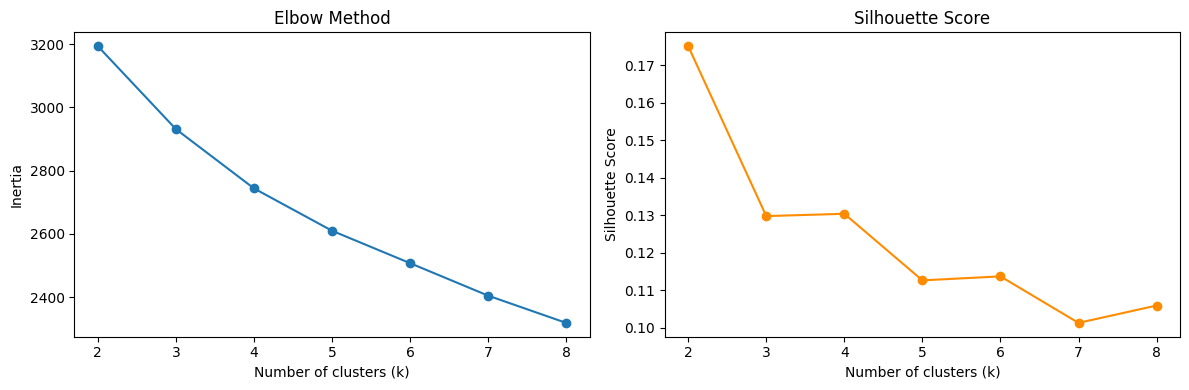

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


The elbow and the silhouette score both point to a small number of clusters. Since the project's real question is "disease vs. no disease", we pick **k = 2** — this also makes the cluster labels directly comparable to `target_binary`.


In [6]:
k_final = 2
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
model_df["kmeans_cluster"] = kmeans_final.fit_predict(X_scaled)

print("Overall silhouette score (k=2):", round(silhouette_score(X_scaled, model_df["kmeans_cluster"]), 3))
model_df["kmeans_cluster"].value_counts()


Overall silhouette score (k=2): 0.175


kmeans_cluster
0    184
1    113
Name: count, dtype: int64

### Comparing K-Means clusters with the actual diagnosis

We now bring back `target_binary` **only to check**, not to influence, the clustering — the same check performed in the Week 4 unsupervised notebook, but here produced from Week 5's own K-Means workflow (elbow + silhouette-selected k).


In [7]:
pd.crosstab(model_df["kmeans_cluster"], model_df["target_binary"],
            rownames=["K-Means cluster"], colnames=["Actual diagnosis (0=no disease, 1=disease)"])


"Actual diagnosis (0=no disease, 1=disease)",0,1
K-Means cluster,,
0,147,37
1,13,100


## 2. DBSCAN & Hierarchical Clustering — Day 2
### *(Part 1: Risk Grouping — with a first look ahead to Part 2: Anomaly Screening)*

**Why go beyond K-Means?** K-Means assumes round-shaped clusters and forces every patient into a cluster, even ones that don't really belong anywhere ("outliers"). On Day 2 we learned two alternatives:

- **DBSCAN** — groups points by density and can mark unusual patients as **noise** (label `-1`) instead of forcing them into a cluster. This is why DBSCAN plays a double role in this project: it groups patients for Part 1, and its noise points double as an early, simple anomaly signal that we will revisit in Part 2 (Section 4).
- **Hierarchical Clustering** — builds a tree of nested clusters (a **dendrogram**), useful to see how patients merge together step by step.

We apply both to the same scaled clinical features, then compare all three clustering methods on this dataset.

### DBSCAN

In [8]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)
model_df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

n_noise = (model_df["dbscan_cluster"] == -1).sum()
n_clusters_dbscan = len(set(model_df["dbscan_cluster"])) - (1 if n_noise > 0 else 0)

print("DBSCAN clusters found (excluding noise):", n_clusters_dbscan)
print("Patients flagged as noise (-1):", n_noise)
model_df["dbscan_cluster"].value_counts()


DBSCAN clusters found (excluding noise): 1
Patients flagged as noise (-1): 110


dbscan_cluster
 0    187
-1    110
Name: count, dtype: int64

`eps` and `min_samples` control how DBSCAN defines "dense enough to be a cluster". With clinical data like this — continuous, overlapping, no natural well-separated groups — DBSCAN tends to find one large dense cluster plus a handful of noise points, rather than clean disease/no-disease groups. That's an expected, informative result: it tells us the two diagnosis groups don't form dense, well-separated regions in feature space.


### Hierarchical Clustering & Dendrogram

A dendrogram on all 303 patients is hard to read, so we plot it **truncated** to the last merges (the ones that matter most for deciding how many clusters to keep), same approach as Day 2.


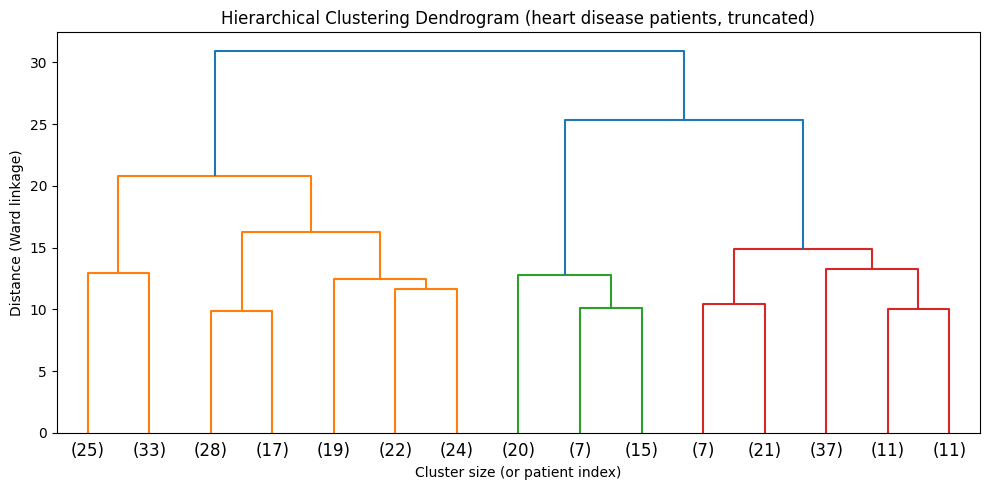

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode="lastp", p=15, show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (heart disease patients, truncated)")
plt.xlabel("Cluster size (or patient index)")
plt.ylabel("Distance (Ward linkage)")
plt.tight_layout()
plt.show()


In [10]:
hier = AgglomerativeClustering(n_clusters=2, linkage="ward")
model_df["hier_cluster"] = hier.fit_predict(X_scaled)

pd.crosstab(model_df["hier_cluster"], model_df["target_binary"],
            rownames=["Hierarchical cluster"], colnames=["Actual diagnosis (0=no disease, 1=disease)"])


"Actual diagnosis (0=no disease, 1=disease)",0,1
Hierarchical cluster,,
0,43,86
1,117,51


### Comparing K-Means, DBSCAN, and Hierarchical Clustering on this project

| Method | Behaviour on the heart disease data | Fit for this project |
|---|---|---|
| **K-Means (k=2)** | Forces every patient into one of 2 round-ish clusters | Best match to a binary "disease / no disease" question |
| **DBSCAN** | Finds one dense group + a few noise points, doesn't split into two balanced groups | Better suited to flagging **unusual patients**, not to reproducing a diagnosis split |
| **Hierarchical (Ward, 2 clusters)** | Similar result to K-Means when cut at 2 clusters, but the dendrogram also shows how clusters would split at 3, 4, 5... | Useful to *explore* whether more than 2 natural patient groups exist |

**Takeaway for the project:** K-Means (and Hierarchical Clustering cut at 2 groups) align reasonably well with the actual diagnosis, while DBSCAN is more useful here as an early **anomaly indicator** — the patients it marks as noise are worth a closer look, which connects directly to the anomaly detection step in Section 4.


## 3. Dimensionality Reduction with PCA — Day 3
### *(Part 1: Risk Grouping)*

The dataset has 13 clinical features — too many to visualize directly. PCA compresses them into a smaller number of components that keep as much of the original variance as possible, exactly as practiced on Day 3: scale first, check the explained variance ratio, then decide how many components to keep.

For Part 1's question, PCA gives us a way to actually *see* whether the patient groups found by clustering hold together in a low-dimensional view.

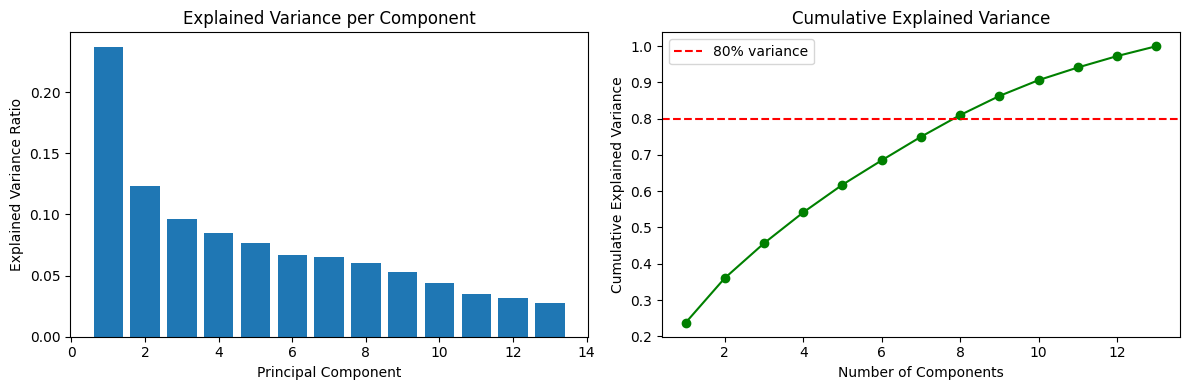

Variance explained by first 2 components: 36.0 %


In [11]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained) + 1), explained)
axes[0].set_title("Explained Variance per Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="green")
axes[1].axhline(0.8, color="red", linestyle="--", label="80% variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Variance explained by first 2 components:", round(cumulative[1] * 100, 1), "%")


With 13 clinical features, no single pair of components captures most of the variance — a reminder that heart disease risk is genuinely multi-factorial. Following the Day 3 workflow, we still reduce to **2 components purely for visualization** (not for modeling), and color each patient by their actual diagnosis to see whether PCA space separates the two groups.


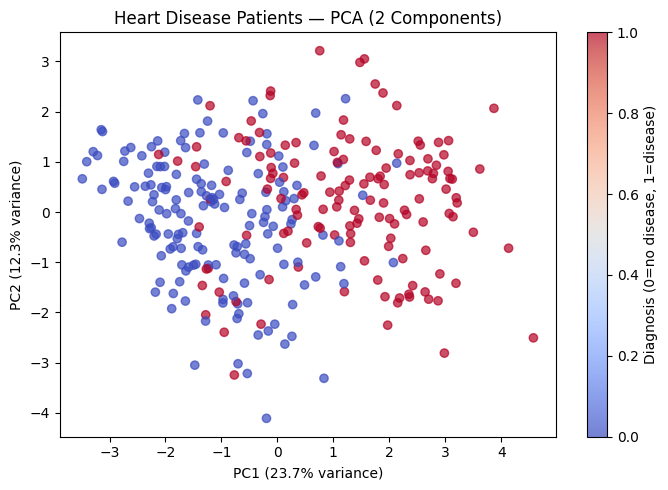

In [12]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("Heart Disease Patients — PCA (2 Components)")
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.colorbar(scatter, label="Diagnosis (0=no disease, 1=disease)")
plt.tight_layout()
plt.show()


## 4. t-SNE & Anomaly Detection — Day 4
### *(t-SNE → Part 1: Risk Grouping · Isolation Forest → Part 2: Anomaly Screening)*

### t-SNE vs. PCA

PCA keeps the *global* variance of the data. **t-SNE** instead focuses on keeping patients who are similar in the original 13-dimensional space close together in the 2D plot — it's a purely visual tool (its axes have no direct clinical meaning and should never be fed into a model), used here to see the patient groups from a different angle than PCA, closing out Part 1's question with one more view of the same clusters.

With Part 1 covered, the rest of this section switches to Part 2's question — *are there patients whose records look unusual and deserve a closer look?* — using Isolation Forest as the dedicated anomaly-detection tool.

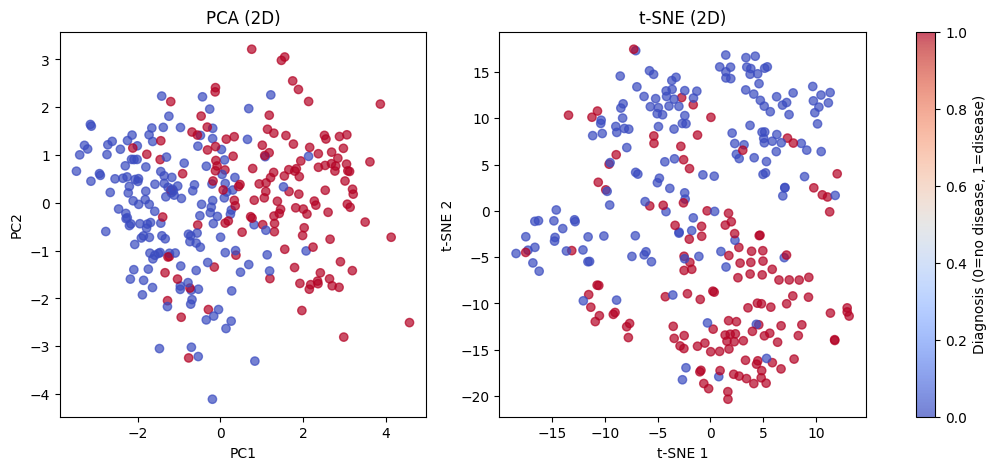

In [13]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
axes[1].set_title("t-SNE (2D)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

fig.colorbar(sc2, ax=axes.ravel().tolist(), label="Diagnosis (0=no disease, 1=disease)")
plt.show()


### Anomaly Detection with Isolation Forest
### *(Part 2: Anomaly Screening)*

Some patient records may be **clinically unusual** — an extreme cholesterol value, an unexpected combination of symptoms — even if we don't have a label for "this record is unusual". Isolation Forest detects such points by how *few splits* it takes to isolate them from the rest of the data: unusual points isolate faster.

The `contamination` parameter is **our own estimate** of what fraction of patients are unusual — the model does not discover this number on its own. We use `0.05` (assume ~5% of records are unusual), the same kind of assumption practiced on Day 4.

In [14]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
model_df["anomaly"] = iso_forest.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal

n_anomalies = (model_df["anomaly"] == -1).sum()
print(f"Flagged as anomalies: {n_anomalies} out of {len(model_df)} patients")

model_df.loc[model_df["anomaly"] == -1, feature_cols + ["target_binary"]].head(10)


Flagged as anomalies: 15 out of 297 patients


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_binary
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
27,66,0,1,150,226,0,0,114,0,2.6,3,0.0,3.0,0
90,62,0,4,160,164,0,2,145,0,6.2,3,3.0,7.0,1
125,56,0,4,200,288,1,2,133,1,4.0,3,2.0,7.0,1
181,59,1,1,178,270,0,2,145,0,4.2,3,0.0,7.0,0
184,42,1,3,120,240,1,0,194,0,0.8,3,0.0,7.0,0
185,66,1,2,160,246,0,0,120,1,0.0,2,3.0,6.0,1
186,54,1,2,192,283,0,2,195,0,0.0,1,1.0,7.0,1
190,62,0,4,138,294,1,0,106,0,1.9,2,3.0,3.0,1
208,38,1,1,120,231,0,0,182,1,3.8,2,0.0,7.0,1


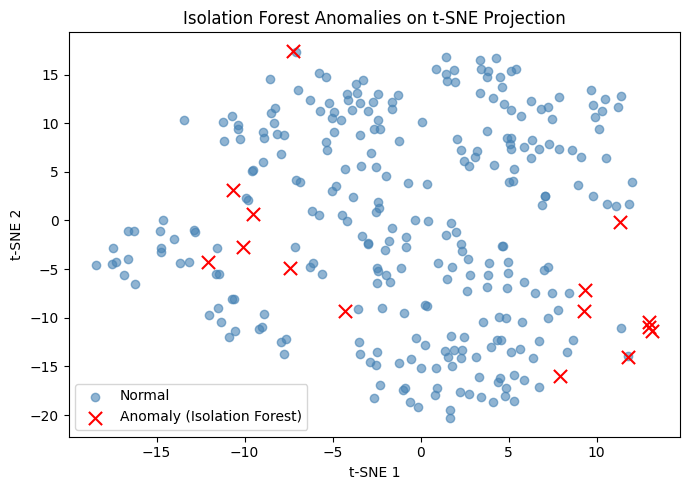

In [15]:
plt.figure(figsize=(7, 5))
normal_mask = model_df["anomaly"] == 1
plt.scatter(X_tsne[normal_mask, 0], X_tsne[normal_mask, 1],
            c="steelblue", label="Normal", alpha=0.6)
plt.scatter(X_tsne[~normal_mask, 0], X_tsne[~normal_mask, 1],
            c="red", label="Anomaly (Isolation Forest)", marker="x", s=90)
plt.title("Isolation Forest Anomalies on t-SNE Projection")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()


### Connecting back to DBSCAN noise (Section 2) — where Part 1 and Part 2 meet

DBSCAN's noise points (`-1`), found back in Part 1 while grouping patients, were an early, simple form of anomaly detection. Now that Part 2 has its own dedicated anomaly detector, we check how much the two overlap — if Isolation Forest (Part 2) agrees with DBSCAN's noise points (a by-product of Part 1), it strengthens the case that those patients really are unusual, and shows the two parts of this notebook reinforcing rather than duplicating each other.

In [16]:
overlap = pd.crosstab(model_df["dbscan_cluster"] == -1, model_df["anomaly"] == -1,
                       rownames=["DBSCAN noise"], colnames=["Isolation Forest anomaly"])
overlap


Isolation Forest anomaly,False,True
DBSCAN noise,,
False,187,0
True,95,15


## 5. Conclusion — What Week 5 Added to the Cardiac Patient Monitoring Project

This notebook set out to answer two concrete questions about the same 303 patients, and each Week 5 method mapped to one of them:

**Part 1 — Risk Grouping: "Can we identify similar patient groups without knowing their diagnosis?"**

| Method | What it revealed about the heart disease data |
|---|---|
| **K-Means (k=2, elbow + silhouette)** | Two clusters emerge that partially align with actual diagnosis, without ever seeing the label |
| **DBSCAN** | The two diagnosis groups are not cleanly density-separated; DBSCAN instead surfaces a small set of atypical patient records (feeding into Part 2 below) |
| **Hierarchical Clustering** | Confirms the 2-cluster split seen in K-Means, and the dendrogram shows how finer patient sub-groups could be explored |
| **PCA** | 13 clinical features compress to 2 components that only explain part of the variance — heart disease risk is genuinely multi-factorial, not reducible to 1–2 dimensions |
| **t-SNE** | Gives a different, purely visual look at how patients group together compared to PCA, useful for exploration only |

**Answer:** yes, to a degree — K-Means and Hierarchical Clustering both find a 2-group split that partially lines up with the real diagnosis, even though the two classes overlap enough in feature space that no method separates them perfectly.

**Part 2 — Anomaly Screening: "Are there patients whose records look unusual and deserve a closer look?"**

| Method | What it revealed about the heart disease data |
|---|---|
| **DBSCAN noise points** | An early, incidental signal — points too sparse to belong to the main dense region |
| **Isolation Forest** | A dedicated anomaly detector; flags a small number (≈5%) of patients as clinically unusual, several of which overlap with DBSCAN's noise points |

**Answer:** yes — a small subset of patients is consistently flagged as atypical by two independent methods, which is a stronger signal than either method alone.

**Overall:** the two parts complement rather than duplicate each other. Part 1's five methods each add a different lens on the same grouping question — partitioning, density, hierarchy, and two ways of visualizing the result — while Part 2 takes DBSCAN's incidental noise points and Isolation Forest's dedicated scan and cross-checks them into a short list of records worth a second look. Nothing here is a leftover topic bolted on to cover the syllabus: every method has a clear job in one of the two stories above.

**Limitations:** same as the Week 4 project — this is for educational purposes only, the dataset is small (303 patients) and from a single clinical source, and none of this output should be used for real clinical decision-making.